<a href="https://colab.research.google.com/github/HM-Mahibullah/ComputerVision/blob/main/pretrainedModelExampleBoneFracture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
import numpy as np
from glob import glob
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense,Flatten,Dropout,Lambda
import matplotlib.pyplot as plt

In [ ]:
tf.__version__

In [5]:
IMAGE_SIZE = [224, 224] # Define your desired image size, e.g., 224x224 pixels
vgg16 = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
for layer in vgg16.layers:
    print(layer.trainable)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [13]:
# Create the hidden .kaggle directory in the root home folder
!mkdir -p ~/.kaggle

# Copy your uploaded kaggle.json API key token into that directory
!cp kaggle.json ~/.kaggle/

In [14]:
!pwd

/content


In [15]:
!kaggle datasets download osamajalilhassan/bone-fracture-dataset

Dataset URL: https://www.kaggle.com/datasets/osamajalilhassan/bone-fracture-dataset
License(s): unknown
100% 173M/173M [00:10<00:00, 16.7MB/s]



In [ ]:
!unzip /content/bone-fracture-dataset.zip

In [17]:
folders = glob('/content/BoneFractureDataset/training/*')
folders

num_of_class = len(folders)
num_of_class

model = Sequential()
model.add(vgg16)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(num_of_class,activation='softmax'))

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,986 (80.64 MB)

 Trainable params: 21,137,986 (80.64 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ট্রেইনিং ইমেজের জন্য অগমেন্টেশন জেনারেটর তৈরি করা
train_datagen = ImageDataGenerator(
    rescale=1./255,          # পিক্সেল ভ্যালু ০-২৫৫ থেকে কমিয়ে ০-১ এর মধ্যে আনা
    shear_range=0.2,         # ছবিকে কিছুটা বাঁকা করা
    zoom_range=0.2,          # ছবিকে জুম করা
    horizontal_flip=True     # ছবিকে ডানে-বামে ফ্লিপ করা
)

# টেস্ট বা ভ্যালিডেশন ইমেজের জন্য শুধু রিস্কেল জেনারেটর
test_datagen = ImageDataGenerator(rescale=1./255)

In [22]:
train_path = '/content/BoneFractureDataset/training/'
training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 8863 images belonging to 2 classes.


In [25]:
valid_path = '/content/BoneFractureDataset/testing'
test_set = test_datagen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 600 images belonging to 2 classes.


In [26]:
r = model.fit(
    training_set,
    validation_data=test_set,
    epochs=10,
    steps_per_epoch=len(training_set),
    validation_steps=len(test_set)
)


Epoch 1/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 276s 827ms/step - accuracy: 0.5066 - loss: 0.7911 - val_accuracy: 0.6000 - val_loss: 0.6913
Epoch 2/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 162s 585ms/step - accuracy: 0.5016 - loss: 0.6932 - val_accuracy: 0.6000 - val_loss: 0.6912
Epoch 3/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 160s 578ms/step - accuracy: 0.5055 - loss: 0.6932 - val_accuracy: 0.6000 - val_loss: 0.6919
Epoch 4/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 160s 577ms/step - accuracy: 0.4992 - loss: 0.6932 - val_accuracy: 0.6000 - val_loss: 0.6901
Epoch 5/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 205s 587ms/step - accuracy: 0.5055 - loss: 0.6931 - val_accuracy: 0.6000 - val_loss: 0.6901
Epoch 6/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 161s 580ms/step - accuracy: 0.5007 - loss: 0.6932 - val_accuracy: 0.6000 - val_loss: 0.6900
Epoch 7/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 202s 580ms/step - accuracy: 0.5055 - loss: 0.6932 - val_accuracy: 0.6000 - val_loss: 0.6908
Epoch 8/10
277/277 ━━━━━━━━━━━━━━━━━━━━ 160s 577ms/step - accuracy: 0.5055 -

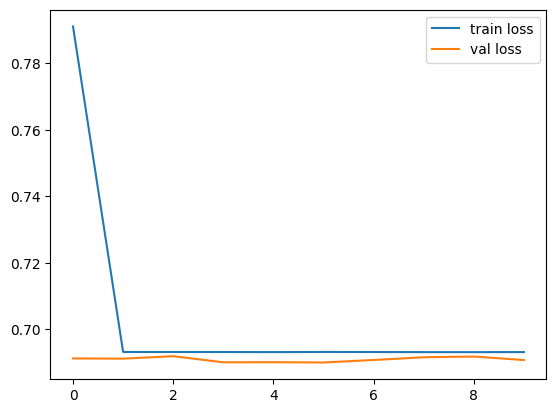

<Figure size 640x480 with 0 Axes>

In [27]:
import matplotlib.pyplot as plt

# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

In [28]:
model.evaluate(test_set)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.6000 - loss: 0.6908


[0.6907691955566406, 0.6000000238418579]

In [29]:
from tensorflow.keras.models import load_model

model.save('model_vgg16.h5')



In [31]:
model = load_model("model_vgg16.h5")

from tensorflow.keras.preprocessing import image

img = "/content/BoneFractureDataset/training/fractured/10-rotated1-rotated1-rotated1.jpg"

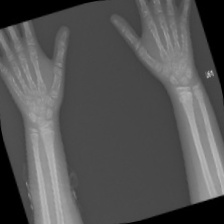

In [32]:
img = image.load_img(img, target_size=(224, 224))
img

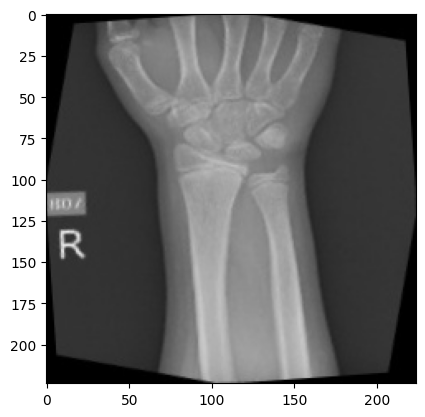

In [39]:
Z = plt.imread('/content/BoneFractureDataset/testing/not_fractured/1-rotated1-rotated1-rotated1-rotated1.jpg')
plt.imshow(Z)

In [40]:
Z.shape

x = Z / 255

from keras.applications.vgg16 import preprocess_input
import numpy as np
x = np.expand_dims(x, axis=0)
img_data = preprocess_input(x)

output = model.predict(img_data)
output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[0.5061328 , 0.49386725]], dtype=float32)

In [41]:
output = model.predict(img_data)
output

result = np.argmax(output, axis=1)
result

if result[0] == 0:
    prediction = 'Sure fracture'
    print(prediction)
else:
    prediction = 'Not Fracture'
    print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Sure fracture
